# Asymmetric Cryptography

1. L'assunto nascosto della crittografia simmetrica: le chiavi sono **già condivise**.
2. La soluzione ingenua (una chiave per ogni coppia di peer) e la sua **esplosione combinatoria**.
3. Si può usare la *sola* crittografia simmetrica per generare un segreto condiviso su un canale insicuro? Sì (**Merkle Puzzles**), ma con prestazioni pessime.


In [58]:
%load_ext autoreload
%autoreload 2
from utils import *


random.seed(42)
print("=" * 70)
print("✓ Environment ready")
print("=" * 70)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Environment ready


## 1. Recall on Symmetric Cryptography

```
                         canale INSICURO (Eve puo' leggere tutto qui)
                     ┌────────────────────────────────────────────────┐
                     │                                                │
   Alice             │                                                │             Bob
┌──────────┐    ┌────┴─────┐             ciphertext C           ┌─────┴────┐    ┌──────────┐
│ messaggio│──▶│  Encrypt │──────────────────────────────────▶│  Decrypt │──▶│ messaggio│
│    M     │    │  E(K, M) │                                    │  D(K, C) │    │    M     │
└──────────┘    └────┬─────┘                                    └─────┬────┘    └──────────┘
                     │                                                │
                     └─────────────────────  K  ──────────────────────┘

```

- $K$ must be **known in advance** from both communicating parties because non passa sul canale insicuro
- The secrecy of the scheme rely on the secrecy of the key 
- How the communicating parties obtain that key 



## 2. Key Distribution

Questo problema e' noto come distribuzione delle chiavi e gli approcci sono:

- precondivisione manuale
- meccanismi autoamtici

### Pairwise 

L'idea più semplice: ogni coppia di persone che potrebbe voler comunicare si scambia una chiave *una tantum*, magari di persona, in anticipo (es. su una chiavetta USB, a voce).  
Questo implica che con $N$ nodi nella rete il numero di chiavi necessarie e' pari a:

$$\binom{N}{2} = \frac{N(N-1)}{2}$$

Con $N$ peer nella rete, quante
chiavi servono in totale, se ognuno vuole poter parlare con chiunque altro?


In [59]:
for n in [2, 5, 10, 50, 100, 1000, 10000]:
    print(f"N = {n:>5} peer  ->  {num_pairwise_keys(n):>10} chiavi pre-condivise necessarie")

N =     2 peer  ->           1 chiavi pre-condivise necessarie
N =     5 peer  ->          10 chiavi pre-condivise necessarie
N =    10 peer  ->          45 chiavi pre-condivise necessarie
N =    50 peer  ->        1225 chiavi pre-condivise necessarie
N =   100 peer  ->        4950 chiavi pre-condivise necessarie
N =  1000 peer  ->      499500 chiavi pre-condivise necessarie
N = 10000 peer  ->    49995000 chiavi pre-condivise necessarie


### Interactive representation


In [60]:
interact(draw_peer_key_graph, n=IntSlider(value=8, min=2, max=40, step=1, description="N peer"));

interactive(children=(IntSlider(value=8, description='N peer', max=40, min=2), Output()), _dom_classes=('widge…

**Takeaway**: 

- La pre-condivisione pairwise funziona per un piccolo gruppo statico (es. due server che si parlano da sempre)
- Per reti aperte o dinamiche (internet, reti IoT) questo approccio e' impensabile

Serve un modo per **generare** un segreto condiviso al momento, su un canale che l'attaccante può ascoltare.


## 3. Key Exchange simmetrici? Merkle Puzzles

- **Reference**: "[*Secure communications over insecure channels*](https://dl.acm.org/doi/10.1145/359460.359473)"

**Idea (Merkle, 1974)**: Alice prepara $N$ "puzzle": ciascuno è una chiave di sessione cifrata con una
chiave-puzzle volutamente debole (pochi bit). Li invia tutti a Bob, in chiaro, sul canale insicuro. Bob ne
sceglie uno a caso e lo rompe per forza bruta (costo $O(K)$, con $K$ = spazio delle chiavi-puzzle). Da quel
momento Alice e Bob condividono la chiave di sessione contenuta in quel puzzle — **senza essersi mai
incontrati prima**, e usando solo un cifrario simmetrico.

**Il punto cruciale**: un attaccante Eve, per trovare la STESSA chiave di sessione che useranno Alice e
Bob, deve nel caso peggiore rompere tutti gli $N$ puzzle: costo $O(N \cdot K)$.   
Con $K \approx N$ (dimensionamento tipico), il costo di Eve è $O(N^2)$ contro l'$O(N)$ di Bob: un gap **quadratico**.


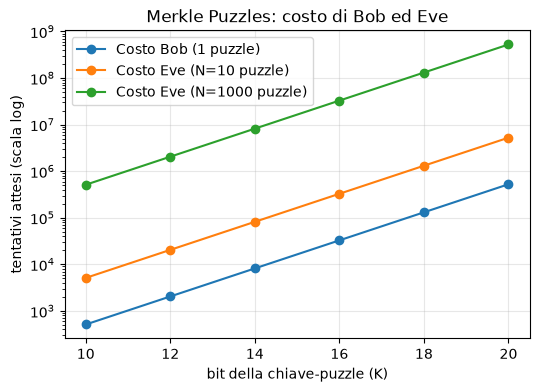

Per dare a Eve un costo di ~2^40 con K=20 bit, servono N = 2e+06 puzzle:
Alice dovrebbe INVIARE quel numero di puzzle sul canale. Non è praticabile.


In [61]:
Ks = [10, 12, 14, 16, 18, 20]

plot_merkle_cost(
    Ks,
    N_values=[10, 1000]
)

print(f"Per dare a Eve un costo di ~2^40 con K=20 bit, servono N = {2**40 / (2**20/2):.0e} puzzle:")
print("Alice dovrebbe INVIARE quel numero di puzzle sul canale. Non è praticabile.")

### Problemi

I Merkle Puzzles mostrano che è possibile stabilire un segreto condiviso
senza averne uno pre-condiviso, ma presentano due problemi principali:

- **Troppe informazioni da inviare**  
  Per aumentare il costo dell'attaccante, Alice deve generare e inviare un
  numero elevato di puzzle.

- **Vantaggio non così significativo**  
  Il costo per Eve è maggiore di quello di Bob solo di un fattore $N$:
  
  $$
  \text{costo Eve} \approx N \cdot \text{costo Bob}.
  $$
  
  Non otteniamo quindi una vera asimmetria computazionale tra i due.

## 4. Trapdoor

Il problema che abbiamo visto con la distribuzione delle chiavi ci porta a una nuova idea.

Vorremmo avere una funzione che sia:

- **facile da calcolare** per chiunque;
- **difficile da invertire** per chi non conosce un segreto;
- **facile da invertire** per chi possiede il segreto.

Questa struttura prende il nome di **trapdoor function**.

L'idea può essere rappresentata così:

$$
x \xrightarrow{\text{facile}} f(x)
$$

Chiunque può calcolare $f(x)$.

Ma, dato $y=f(x)$, recuperare $x$ dovrebbe essere computazionalmente difficile:

$$
y \xrightarrow{\text{difficile}} x
$$

A chi conosce un'informazione segreta, detta **trapdoor**, l'inversione diventa invece molto più semplice:

$$
y \xrightarrow[\text{trapdoor}]{\text{facile}} x
$$

> Questa **asimmetria computazionale** è l'idea fondamentale che cerchiamo
nella crittografia asimmetrica.
